<a href="https://colab.research.google.com/github/ramirezcarlos292/miaad_python_programming/blob/main/practices/Practica_24_RegresionLinealMultiple.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Maestría en Inteligencia Artificial y Analítica de Datos

## Programación para Analítica Descriptiva y Predictiva - Marzo 2025
## Práctica: Práctica: Regresión Lineal Múltiple
---


## Datos del Estudiante

*   Apellidos y Nombre:
*   Matrícula:

---



##  Objetivo de aprendizaje
Al finalizar esta práctica, el estudiante será capaz de **aplicar regresión lineal múltiple utilizando Scikit-Learn para modelar la relación entre varias variables independientes y una variable dependiente**, verificar los supuestos del modelo, interpretar los coeficientes, analizar la correlación entre predictores y evaluar el rendimiento del modelo utilizando métricas como el MSE, RMSE y R².

Datos
Trabajarás con el archivo `advertising.csv`, que contiene información sobre el gasto publicitario en diferentes medios y las ventas obtenidas:

-`TV`: inversión en publicidad televisiva.

-`Radio`: inversión en publicidad en radio.

-`Newspaper`: inversión en publicidad en periódicos.

`Sales`: ventas del producto (variable dependiente).

## Parte 1: Carga de datos y bibliotecas
1. Importa las bibliotecas necesarias.
2. Carga el archivo `advertising.csv`.
3. Muestra las primeras filas del dataframe.
4. Describe estadísticamente las variables.<br>
---
  **La inversión en TV y Newspaper tienen rangos amplios y desviaciones estándar tambien grandes, mientras que la inversión en Radio es la menos variable de las 3.**


In [203]:
# Tu código aquí
from google.colab import drive
drive.mount('/content/mydrive/')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

!wget -P /content/drive/MyDrive/ClassFiles/ https://raw.githubusercontent.com/ramirezcarlos292/miaad_python_programming/refs/heads/main/datasets/advertising.csv

Drive already mounted at /content/mydrive/; to attempt to forcibly remount, call drive.mount("/content/mydrive/", force_remount=True).
--2025-11-01 06:45:44--  https://raw.githubusercontent.com/ramirezcarlos292/miaad_python_programming/refs/heads/main/datasets/advertising.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 4062 (4.0K) [text/plain]
Saving to: ‘/content/drive/MyDrive/ClassFiles/advertising.csv.7’

advertising.csv.7   100%[===================>]   3.97K  --.-KB/s    in 0s      

2025-11-01 06:45:44 (53.2 MB/s) - ‘/content/drive/MyDrive/ClassFiles/advertising.csv.7’ saved [4062/4062]



In [204]:
df = pd.read_csv('/content/drive/MyDrive/ClassFiles/advertising.csv')
df.head()

,TV,Radio,Newspaper,Sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,12.0
3,151.5,41.3,58.5,16.5
4,180.8,10.8,58.4,17.9


In [205]:
df.describe()

,TV,Radio,Newspaper,Sales
count,200.000000,200.000000,200.000000,200.000000
mean,147.042500,23.264000,30.554000,15.130500
std,85.854236,14.846809,21.778621,5.283892
min,0.700000,0.000000,0.300000,1.600000
25%,74.375000,9.975000,12.750000,11.000000
50%,149.750000,22.900000,25.750000,16.000000
75%,218.825000,36.525000,45.100000,19.050000
max,296.400000,49.600000,114.000000,27.000000


## Parte 2: Análisis exploratorio de los datos
### 2.1  Análisis de la Relación Lineal entre la variable dependiente y las independientes
1. Grafica dispersión entre cada variable independiente (`TV`, `Radio`, `Newspaper`) y `Sales`. Usa también regplot.
2. Interpreta visualmente la relación entre variables.

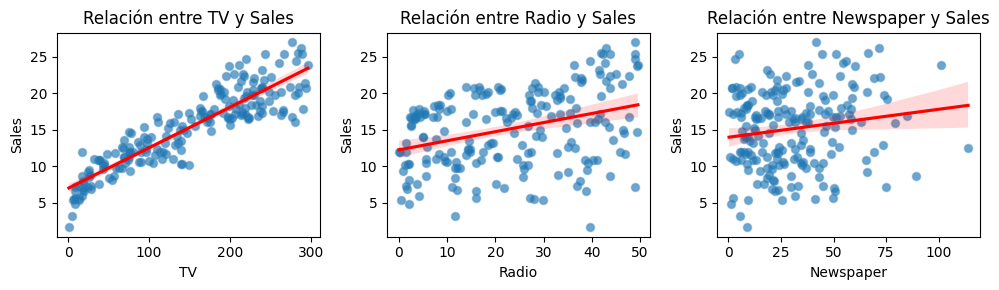

In [206]:
# Gráficos de dispersión
def graf_dispersion(df):
  plt.figure(figsize=(10, 3))
  for i, column in enumerate(df.columns[:-1]):
    plt.subplot(1, 3, i+1)
    sns.scatterplot(x=df[column], y=df['Sales'], alpha=0.5)
    sns.regplot(x=df[column], y=df['Sales'], scatter_kws={'alpha': 0.3}, line_kws={'color':'red'})
    plt.title(f"Relación entre {column} y Sales")
  plt.tight_layout()
  plt.show()

graf_dispersion(df)

### 2.2: Correlación entre variables
1. Calcula la matriz de correlación.
2. Visualízala con un heatmap.
3. Responde: ¿Qué variables están más correlacionadas con `Sales`? ¿Hay correlación alta entre predictores? <br>
**TV es la variable más correlacionada, con 0.9 indicando una correlación muy fuerte positiva.**<br>
**Radio es la segunda variable más correlacionada, con 0.35 indicando una correlación moderada con correlación positiva.**<br>
**Newspaper es la menos correlacionada de las otras 3, pero su 0.16 no es despreciable e indica una correlación positiva.**<br>
**Radio y Newspaper están correlacionados entre sí, con un valor de 0.35 que es moderado, el VIF nos indicará si debemos preocuparnos.**

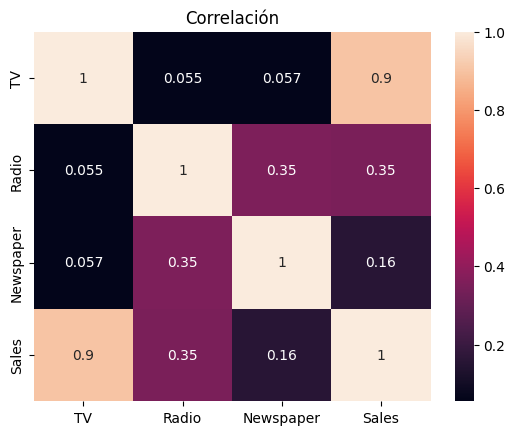

In [207]:
# Correlación y heatmap
sns.heatmap(df.corr(), annot=True)
plt.title('Correlación')
plt.show()

## Parte 3. Multicolinealidad
1. Calcula el VIF (Variance Inflation Factor) para cada predictor.
2. Crea un diagrama de barras  para mostrar el  VIF
3. Interpreta si hay multicolinealidad:
- ¿Alguna variable tiene un VIF mayor a 5 o mayor a 10?<br>
  **Ninguna de las variables indepentientes tuvieron el VIF mayor a 5.**
- ¿Qué implicaciones tiene esto para el modelo?<br>
  **No parece afectar, después de todo las inversiones de cada medio de comunicación no afectan al otro, lo que los influye es el beneficio real después de cada inversión."**

     const     TV  Radio  Newspaper
0      1.0  230.1   37.8       69.2
1      1.0   44.5   39.3       45.1
2      1.0   17.2   45.9       69.3
3      1.0  151.5   41.3       58.5
4      1.0  180.8   10.8       58.4
..     ...    ...    ...        ...
195    1.0   38.2    3.7       13.8
196    1.0   94.2    4.9        8.1
197    1.0  177.0    9.3        6.4
198    1.0  283.6   42.0       66.2
199    1.0  232.1    8.6        8.7

[200 rows x 4 columns]


/tmp/ipython-input-458420864.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='VIF', y='Variable', data=vif_data, palette='coolwarm')


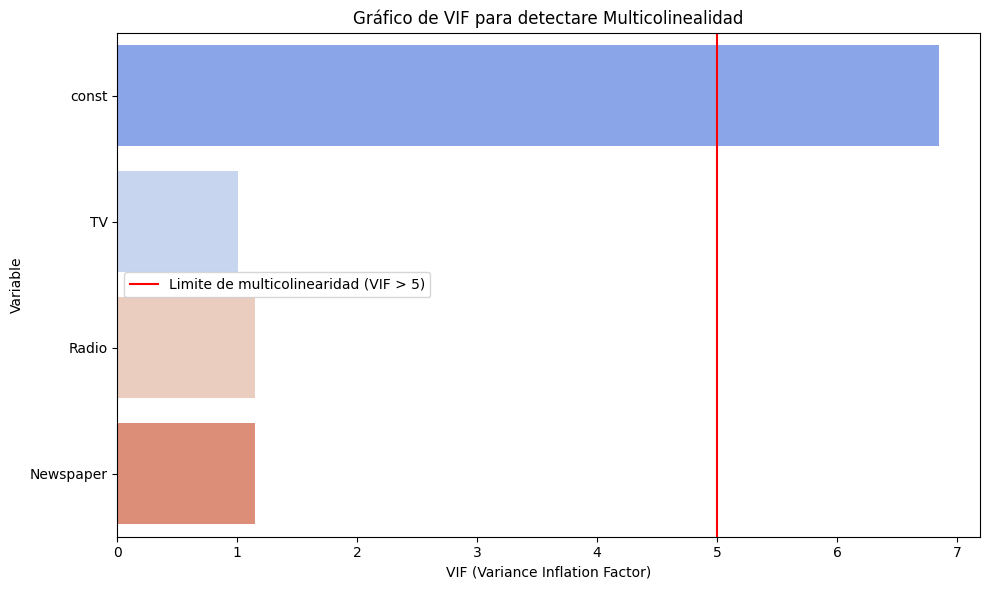

In [208]:
# Multicolinealidad
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant
X = add_constant(df.drop(columns=['Sales']))
print(X)
vif_data = pd.DataFrame()
vif_data['Variable'] = X.columns
vif_data['VIF'] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]

plt.figure(figsize=(10, 6))
sns.barplot(x='VIF', y='Variable', data=vif_data, palette='coolwarm')
plt.axvline(x=5, color='red', label='Limite de multicolinearidad (VIF > 5)')
plt.xlabel('VIF (Variance Inflation Factor)')
plt.legend()
plt.title('Gráfico de VIF para detectare Multicolinealidad')
plt.tight_layout()
plt.show()

## Parte 4: Construcción del Modelo (Todas las variables Independientes), Evaluación

### 4.1 Entrenamiento del Modelo (Todas las Variables Independientes)

1. Entrena un modelo de regresión lineal múltiple usando TV, Radio y Newspaper como variables independientes.
2. Imprime el intercepto y los coeficientes del modelo.
3. Interpreta cada uno:
¿Qué significa cada uno de los coeficientes  en términos de ventas?<br>
  **Para los tres medios de comunicación, tuvieron valores positivos lo que indica un crecimiento en la inversión y en las ventas 'sales', aunque los coeficientes sean pequeños (debido a la escala) indican un crecimiento positivo de las ventas.**<br>
  **En el caso del intercepto, este nos indica que es el valor promedio cuando sus variables predictoras son 0.**


In [209]:
#Entrenamiento del Modelo (Todas las Variables Independientes)

from sklearn.linear_model import LinearRegression

def linear_regression_model(X, y):
  LR = LinearRegression()

  LR.fit(X, y)

  y_pred = LR.predict(X)

  equation = f"Sales = {LR.intercept_} "
  for idx, col in enumerate(X.columns):
    print(f"Coeficiente columna {col}: {LR.coef_[idx]}")
    equation += f" + {LR.coef_[idx]} * {col}"
  print(f"Intercepto: {LR.intercept_}")

  print(equation)

  return X, y, y_pred

X = df.drop(columns='Sales', axis=1)
y = df['Sales']

X, y, y_pred = linear_regression_model(X, y)

Coeficiente columna TV: 0.05444578033757095
Coeficiente columna Radio: 0.10700122823870292
Coeficiente columna Newspaper: 0.00033565792233056224
Intercepto: 4.625124078808653
Sales = 4.625124078808653  + 0.05444578033757095 * TV + 0.10700122823870292 * Radio + 0.00033565792233056224 * Newspaper


### 4.2 Normalidad de los residuos

1. Calcula los residuos: residuos = y - y_pred.

2. Grafica un histograma con KDE de los residuos.

3. ¿Los residuos parecen distribuirse normalmente?<br>
  **Sí, con una cola que se extiende hacia la izquierda y creando un sesgo hacia la derecha.**

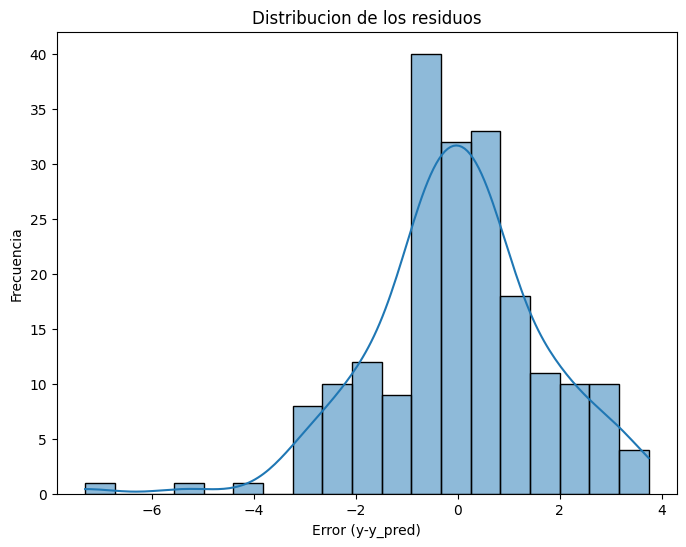

In [210]:
#Normalidad de los residuos
def residuos_calc(y, y_pred):
  residuos = y - y_pred
  plt.figure(figsize=(8, 6))
  sns.histplot(residuos, kde=True)
  plt.xlabel("Error (y-y_pred)")
  plt.ylabel("Frecuencia")
  plt.title("Distribucion de los residuos")
  plt.show()
  return residuos

residuos = residuos_calc(y, y_pred)

### 4.3. Homocedasticidad

1. Grafica los residuos contra los valores predichos.
2. ¿Observas patrones? ¿Los residuos se dispersan aleatoriamente?<br>
  **Sólo unos cuantos datos estan lejos de la linea central, por lo qué podría decirse que los datos no se dispersan aleatoriamente.**

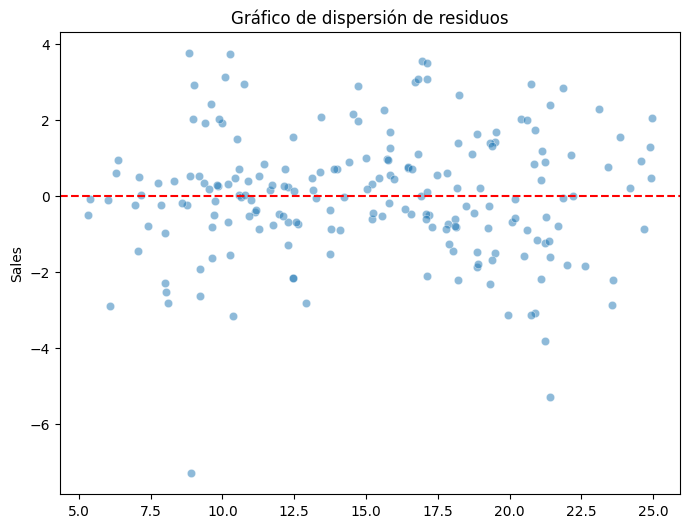

In [211]:
# Homocedasticidad
def homocedasticidad_plot(residuos, y_pred):
  plt.figure(figsize=(8, 6))
  sns.scatterplot(x=y_pred, y=residuos, alpha=0.5)
  plt.axhline(y = 0, color='r', linestyle='--')
  plt.title("Gráfico de dispersión de residuos")
  plt.show()

homocedasticidad_plot(residuos, y_pred)

### 4.4 Q-Q Plot

1. Graficar el Q-Q Plot
2. Interpreta el gráfico: a) Si los puntos se alinean aproximadamente sobre la línea diagonal, los residuos siguen una distribución normal:<br>
**La mayoría de los datos se apegan a la línea central del qq plot, solo en los extremos sucede algo distinto, indicando tal ves presencia de valores atípicos.

b) Desviaciones sistemáticas indican asimetría o colas pesadas.

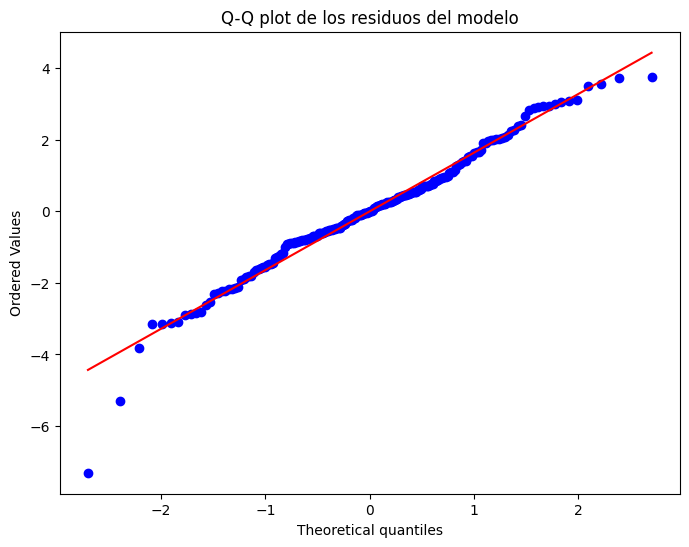

In [212]:
#Q-Q Plot
import scipy.stats as stats
def q_q_plot(residuos):
  plt.figure(figsize=(8, 6))
  stats.probplot(residuos, dist='norm', plot=plt)
  plt.title('Q-Q plot de los residuos del modelo')
  plt.show()

q_q_plot(residuos)

### 4.5. Evaluación del Modelo

1. Calcula las métricas: a) MSE (error cuadrático medio), b) RMSE (raíz del error cuadrático medio), c) R² (coeficiente de determinación)

2. ¿Qué nos dicen estas métricas sobre el ajuste del modelo?<br>
  **MSE y RMSE nos indican el error en las predicciones hechas por el modelo, que parecen no ser altas.**<br>
  **R2 por otro lado nos indica un 90% de variabilidad que absorbe el modelo haciendolo muy robusto ya que esta cercano a 100%.**


In [213]:
#Evaluación del Modelo
from sklearn.metrics import mean_squared_error, root_mean_squared_error, r2_score

def metrics(y, y_pred):
  print(f"MSE: {mean_squared_error(y, y_pred)}")
  print(f"RMSE: {root_mean_squared_error(y, y_pred)}")
  print(f"R2: {r2_score(y, y_pred)}")

metrics(y, y_pred)

MSE: 2.706006147627315
RMSE: 1.6449942697855562
R2: 0.9025912899684558


### 4.6. Visualización de Predicciones

1. Crea un gráfico comparando Sales reales vs Sales predichas.

2. Puedes usar plt.scatter(y_true, y_pred) para evaluar visualmente el ajuste.

3. ¿Qué observas? ¿Qué información puedes obtener de esta gráfica?<br>
  **El valor real de de las ventas se puede predecir usando el modelo, R2 indico un 90% lo que corrobora este gráfico.**

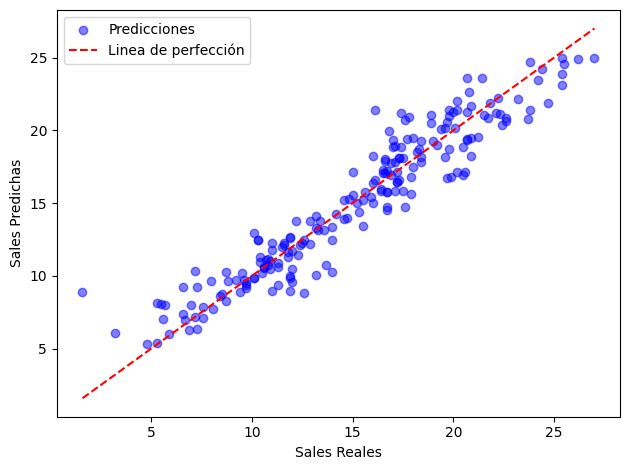

In [214]:
#Visualización de las Predicciones
def q_q_plot_pred(y, y_pred):
  plt.scatter(y, y_pred, alpha=0.5, color='blue', label='Predicciones')
  plt.plot([y.min(), y.max()], [y.min(), y.max()], color='red', linestyle='--', label='Linea de perfección')
  plt.xlabel('Sales Reales')
  plt.ylabel('Sales Predichas')
  plt.legend()
  plt.tight_layout()
  plt.show()

q_q_plot_pred(y, y_pred)

### 4.7 Verificar el impacto de los atributos en el modelo

1. Ajusta el modelo usando statsmodels en lugar de scikit-learn para obtener los valores p.
2. Interpreta los resultados:

 - Observa los valores P>|t| en la tabla de salida.

 - ¿Qué variables tienen p-value menores a 0.05?<br>
  **TV, Radio**

 - ¿Cuál es la conclusión sobre esas variables?<br>
  **No son normales, y que transformaciones podrían ayudarlas a aportar más información al modelo.**

In [215]:
#P-values
import statsmodels.api as sm
from sklearn.preprocessing import StandardScaler

def statistics_model(X, y):
  # scaler = StandardScaler()
  # X_scaled = scaler.fit_transform(X)

  # Agregar una constante al conjunto de datos X_scaled
  X_with_constant = sm.add_constant(X)

  # Ajustar el modelo de regresión lineal utilizando statsmodels
  model_sm = sm.OLS(y, X_with_constant).fit()

  # Imprimir el resumen del modelo
  print(model_sm.summary())

statistics_model(X, y)

                            OLS Regression Results                            
Dep. Variable:                  Sales   R-squared:                       0.903
Model:                            OLS   Adj. R-squared:                  0.901
Method:                 Least Squares   F-statistic:                     605.4
Date:                Sat, 01 Nov 2025   Prob (F-statistic):           8.13e-99
Time:                        06:45:46   Log-Likelihood:                -383.34
No. Observations:                 200   AIC:                             774.7
Df Residuals:                     196   BIC:                             787.9
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          4.6251      0.308     15.041      0.0

##Parte 5:  Construcción del Modelo (sin Multicolinealidad), Evaluación

En el caso de que hayas detectado variables con multicolinealidad. Elimina aquellas que presenten esta característica y realiza los mismos pasos** que la parte 4.**
Escribe cada una de las subsecciones similares a las existentes en la Parte 4.

In [216]:
'''
Aunque existía algo de correlacion entre Radio y Newspaper, VIF descartó multicolinealidad
entre ellas y no eliminaré variables.
'''

'\nAunque existía algo de correlacion entre Radio y Newspaper, VIF descartó multicolinealidad\nentre ellas y no eliminaré variables.\n'

/tmp/ipython-input-1426969375.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X['TV'] = np.sqrt(X['TV'])
/tmp/ipython-input-1426969375.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X['Radio'] = np.exp(X['Radio'])


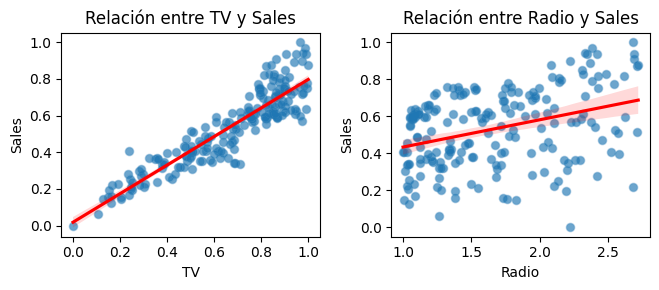

Coeficiente columna TV: 0.7699859814970954
Coeficiente columna Radio: 0.13715441152016153
Intercepto: -0.20519436596204754
Sales = -0.20519436596204754  + 0.7699859814970954 * TV + 0.13715441152016153 * Radio


/tmp/ipython-input-1426969375.py:25: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


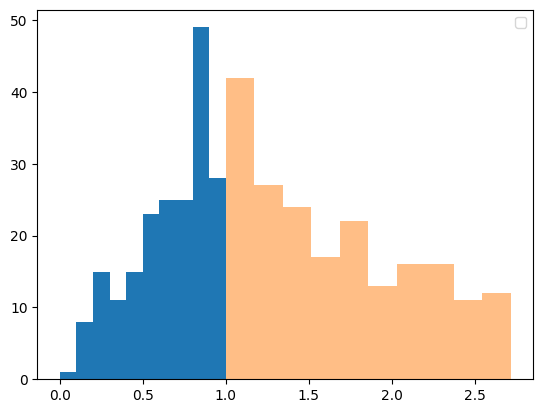

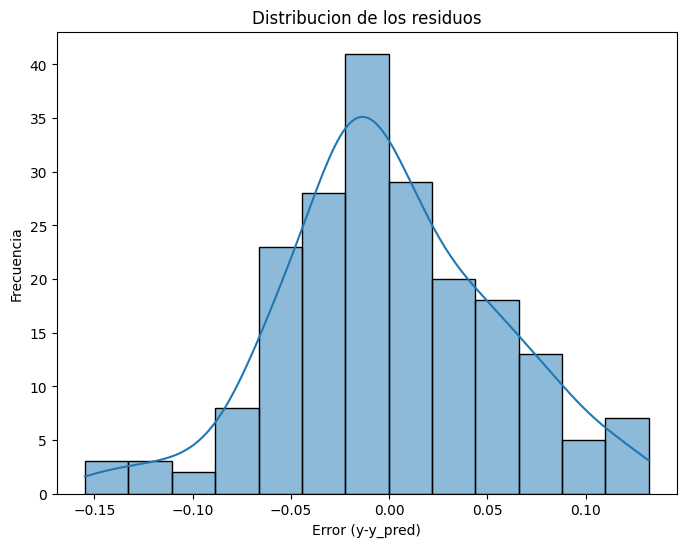

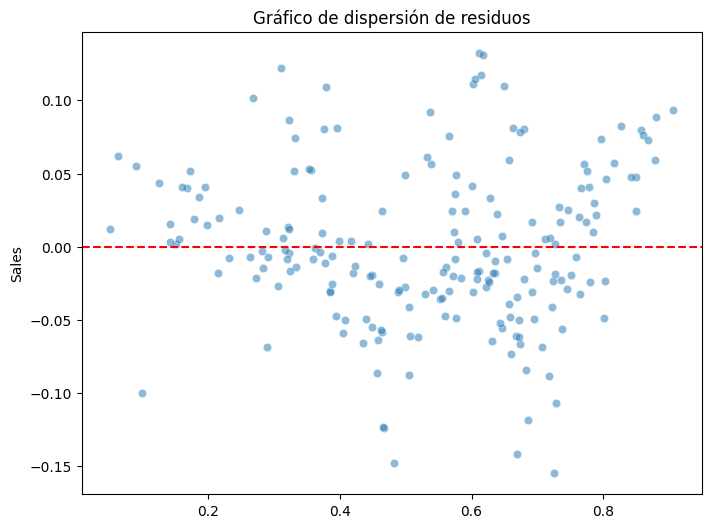

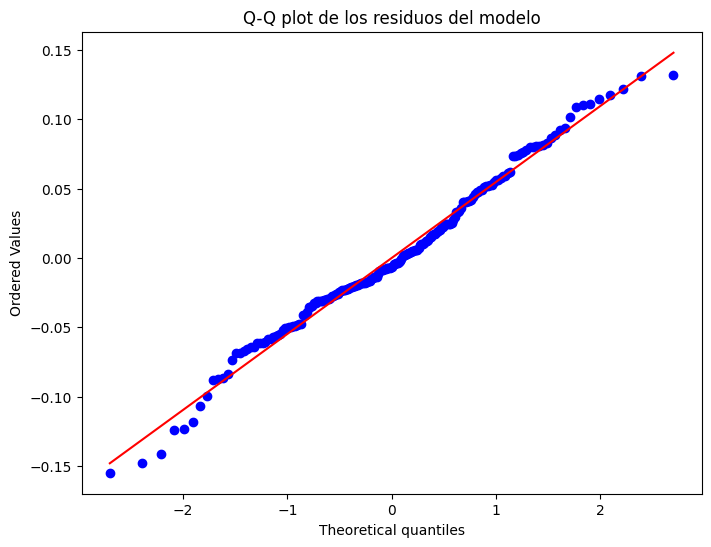

MSE: 0.0029656010379511843
RMSE: 0.05445733226987147
R2: 0.9311269729047872


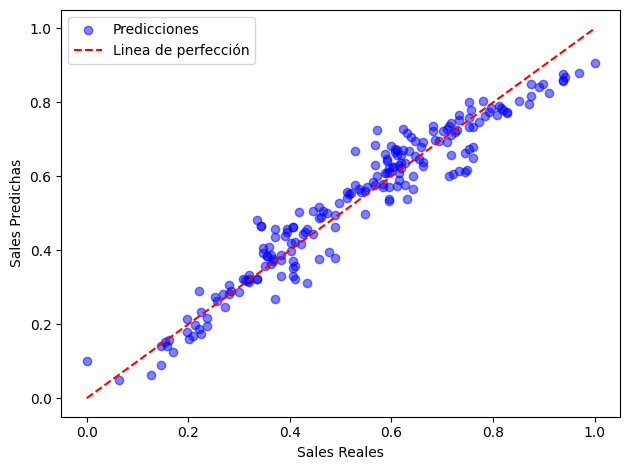

                            OLS Regression Results                            
Dep. Variable:                  Sales   R-squared:                       0.931
Model:                            OLS   Adj. R-squared:                  0.930
Method:                 Least Squares   F-statistic:                     1332.
Date:                Sat, 01 Nov 2025   Prob (F-statistic):          3.53e-115
Time:                        06:45:48   Log-Likelihood:                 298.28
No. Observations:                 200   AIC:                            -590.6
Df Residuals:                     197   BIC:                            -580.7
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.2052      0.017    -12.096      0.0

In [217]:
from scipy.stats import boxcox
from sklearn.preprocessing import RobustScaler, StandardScaler, MinMaxScaler, Normalizer

# Transformaciones MinMaxScaler ayuda al modelo a entender mejor la relacion entre variables independientes
# y la variable dependiente
scaler = MinMaxScaler()
scaled = scaler.fit_transform(df)
scaled_df = pd.DataFrame(scaled, columns=df.columns, index=df.index)


X = scaled_df[['TV', 'Radio']]
X['TV'] = np.sqrt(X['TV'])
X['Radio'] = np.exp(X['Radio'])
# X['Newspaper'] = np.sqrt(X['Newspaper'])
y = scaled_df['Sales']

df2 = pd.concat([X, y], axis=1)

graf_dispersion(df2)


plt.hist(X['TV'], alpha=1.0)
plt.hist(X['Radio'], alpha=0.5)
# plt.hist(X['Newspaper'], alpha=0.5)
plt.legend()

X, y, y_pred = linear_regression_model(X, y)
residuos = residuos_calc(y, y_pred)
homocedasticidad_plot(residuos, y_pred)
q_q_plot(residuos)
metrics(y, y_pred)
q_q_plot_pred(y, y_pred)
statistics_model(X, y)

## Parte 6: Construcción del Modelo (sin variables que no muestran una relación lineal), Evaluación

En el caso de que hayas detectado variables sin una relación lineal con la variable dependiente. Elimina aquellas que presenten esta característica y realiza lo siguiente.

En el caso de que hayas detectado variables sin una relación lineal. Elimina aquellas que presenten esta característica y realiza los mismos pasos** que la parte 4.**
Escribe cada una de las subsecciones similares a las existentes en la Parte 4.

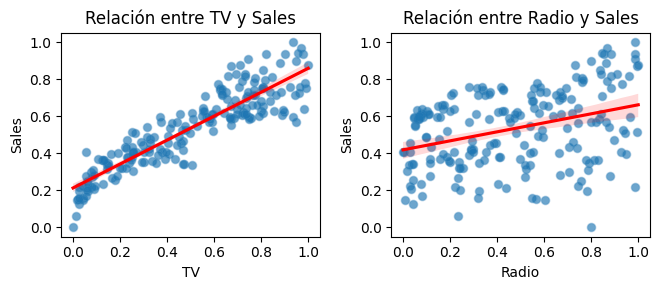

/tmp/ipython-input-25092765.py:25: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


Coeficiente columna TV: 0.6338802239460075
Coeficiente columna Radio: 0.20928577709855667
Intercepto: 0.12082652506337194
Sales = 0.12082652506337194  + 0.6338802239460075 * TV + 0.20928577709855667 * Radio


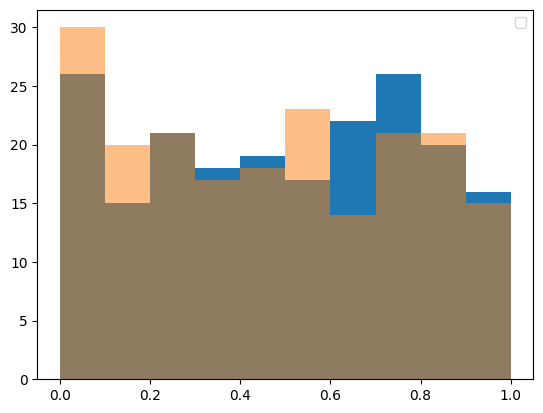

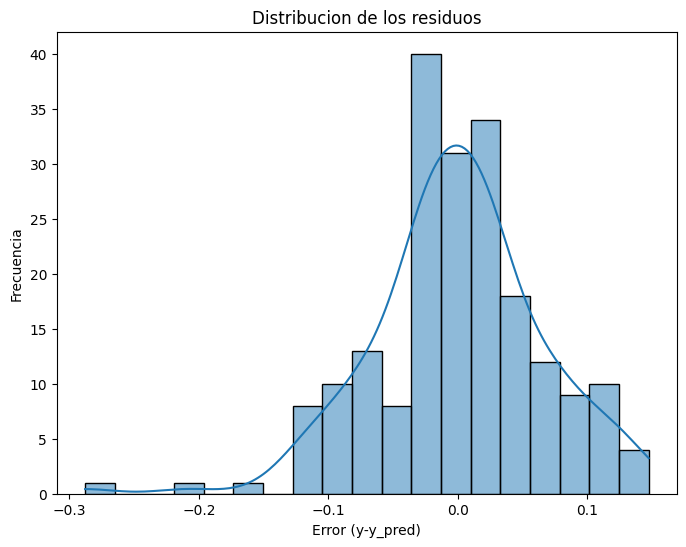

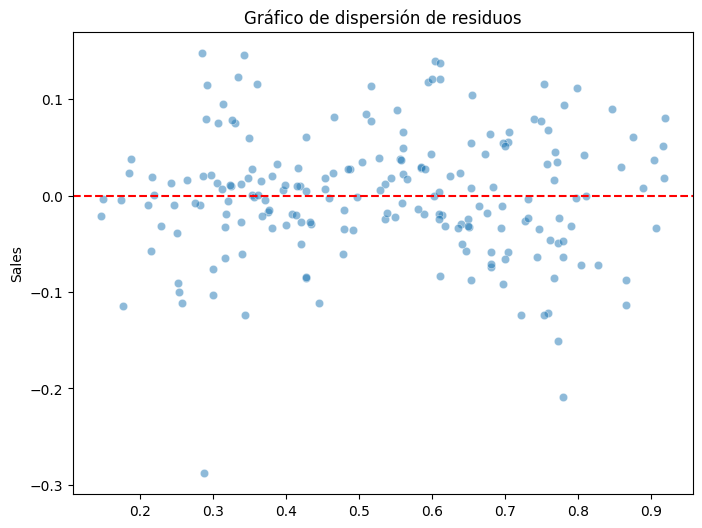

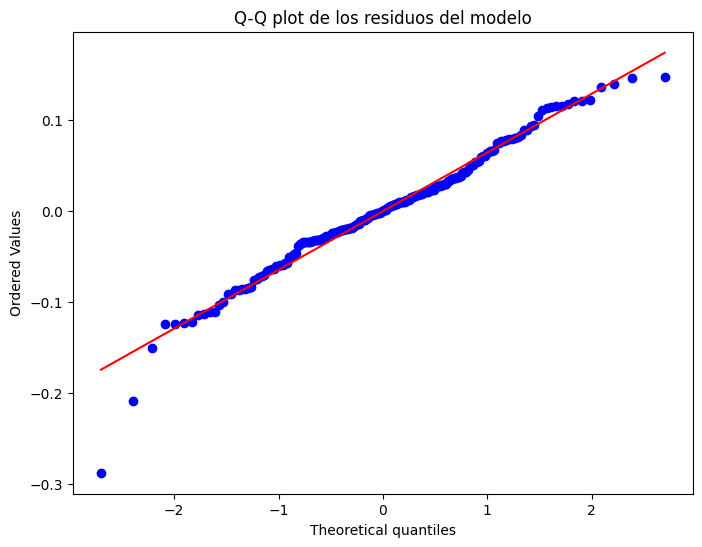

MSE: 0.004194389884499176
RMSE: 0.06476410953992323
R2: 0.9025896186081139


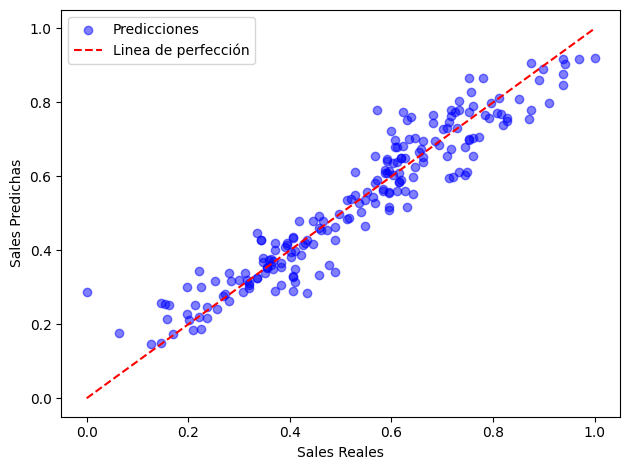

                            OLS Regression Results                            
Dep. Variable:                  Sales   R-squared:                       0.903
Model:                            OLS   Adj. R-squared:                  0.902
Method:                 Least Squares   F-statistic:                     912.7
Date:                Sat, 01 Nov 2025   Prob (F-statistic):          2.39e-100
Time:                        06:45:50   Log-Likelihood:                 263.61
No. Observations:                 200   AIC:                            -521.2
Df Residuals:                     197   BIC:                            -511.3
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.1208      0.011     10.595      0.0

In [218]:
from scipy.stats import boxcox
from sklearn.preprocessing import RobustScaler, StandardScaler, MinMaxScaler, Normalizer

# Transformaciones MinMaxScaler ayuda al modelo a entender mejor la relacion entre variables independientes
# y la variable dependiente
scaler = MinMaxScaler()
scaled = scaler.fit_transform(df)
scaled_df = pd.DataFrame(scaled, columns=df.columns, index=df.index)


X = scaled_df[['TV', 'Radio']]
# X['TV'] = np.sqrt(X['TV'])
# X['Radio'] = np.exp(X['Radio'])
# X['Newspaper'] = np.sqrt(X['Newspaper'])
y = scaled_df['Sales']

df2 = pd.concat([X, y], axis=1)

graf_dispersion(df2)


plt.hist(X['TV'], alpha=1.0)
plt.hist(X['Radio'], alpha=0.5)
# plt.hist(X['Newspaper'], alpha=0.5)
plt.legend()

X, y, y_pred = linear_regression_model(X, y)
residuos = residuos_calc(y, y_pred)
homocedasticidad_plot(residuos, y_pred)
q_q_plot(residuos)
metrics(y, y_pred)
q_q_plot_pred(y, y_pred)
statistics_model(X, y)

##7. Conclusiones.

¿Cuál de los tres modelos construidos fue el mejor?
¿Cuál fue el atributo que mas influencia tiene en las ventas? El atributo con mas influencia en las ventas siempre fue TV, solo lo ayudamos a mejorar, usando la transformacion np.sqrt, tambien nos favorecimos del MinMaxScaler, para que las variables estuvieran en una misma escala. De los tres el descrito en el paso 5: Escalar usando min-max, eliminar variable newspaper que nos ocasionaba ruido y utilizar transormaciones para que TV y Newspaper cambiaran la distribucion de la inversion respectiva e el impacto en ventas, eso ayudo a que los datos se asemejaran más a lineas que se pudieran aproximar con este modelo.

MSE: 0.0029656010379511843
RMSE: 0.05445733226987147
R2: 0.9311269729047872